In [1]:
import datetime as dt 
from astropy.io import fits
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LogNorm
import numpy as np
from ocnus_py import AGCSModel, Univariate, Obs
from scipy.ndimage import gaussian_filter
import matplotlib.animation as animation
from IPython.display import HTML
import json
from matplotlib.gridspec import GridSpec


logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.WARNING)

plt.style.use('dark_background')

In [2]:
def transform_header(hd, modify=False):
    hd.pop('COMMENT')
    hd.pop('HISTORY')

    hd['CDELT1'] *= -1
    hd['CDELT2'] *= -1

    pos = np.array([hd['HEQX_OBS'], hd['HEQY_OBS'], hd['HEQZ_OBS']]) / 1.496e+11
    hdstr = json.dumps(hd)

    return hdstr, pos

def transform_old_header(hd):
    hd.pop('HISTORY')

    hd['CTYPE1'] = 'HPLN-TAN'
    hd['CTYPE2'] = 'HPLT-TAN'
    hd['CDELT1'] *= -0.000277778
    hd['CDELT2'] *= -0.000277778
    
    hd_str = json.dumps(hd)

    return hd_str

with fits.open("../data/solohi1_20220325T113408.fits") as hdul:
    hdr1_str, hdr1_pos = transform_header(dict(hdul[0].header), modify=True)

with fits.open("../data/solohi2_20220325T113808.fits") as hdul:
    hdr2_str, hdr2_pos = transform_header(dict(hdul[0].header))

with fits.open("../data/solohi3_20220325T114356.fits") as hdul:
    hdr3_str, hdr3_pos = transform_header(dict(hdul[0].header))

with fits.open("../data/solohi4_20220325T111957.fits") as hdul:
    hdr4_str, hdr4_pos = transform_header(dict(hdul[0].header))

with fits.open("../data/lascoc3_32695857.fts") as hdul:
    hdrl_str = transform_old_header(dict(hdul[0].header))

In [3]:
# Set up model priors
model = AGCSModel([
    Univariate.uniform("rot_z", -1.0, 1.0),
    Univariate.uniform("rot_y", -0.25, 0.25),
    Univariate.uniform("rot_x", -3.5, 3.14),
    Univariate.constant("r_0rs", 20.0),
    Univariate.uniform("d_1au", 0.05, 0.35),
    Univariate.uniform("hw", np.deg2rad(15), np.deg2rad(90)),
    Univariate.uniform("nfac", 0.5, 1.0),
    Univariate.uniform("cs_delta", 1.0, 2.0),
    Univariate.uniform("speed", 700.0, 1500.0),
    Univariate.uniform("b_scale", 10.0, 30.0),
    Univariate.uniform("tau", -50.0, 0.0),
    Univariate.constant("sw_speed", 400.0),
    Univariate.constant("sw_gamma", 1.0),
])

params = np.array([[
    np.deg2rad(12.5),   # longitude
    np.deg2rad(0.0),  # latitude
    np.deg2rad(-95.0),    # inclination
    20.0, 
    0.3,                # diameter (real width is multiplied by delta)
    np.deg2rad(45),
    0.6, 
    2.00,   
    800.0, 
    25.0, 
    -50, 
    400.0, 
    1.0
]])

STEP = 3
N = 40

obs = Obs(
    [STEP * 3600 * i for i in range(N)],
    np.array([[1.0, 0.0, 0.0] for _ in range(N)]),
    [hdrl_str for _ in range(N)],
    None
)

data = model.simulate_rwl(obs, params)

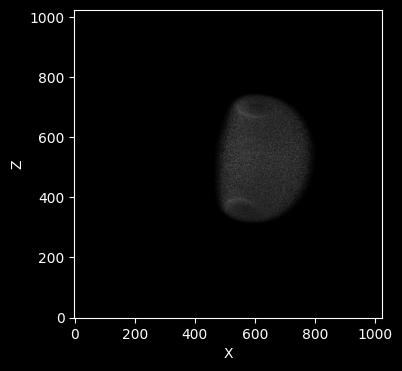

In [4]:
plt.figure(figsize=(4, 4))
plt.imshow(data.get(0)[1], cmap='gist_gray', origin='lower', vmin=0)
plt.xlabel("X")
plt.ylabel("Z")
plt.show()

In [5]:
obs_1 = Obs(
    [STEP * 3600 * i for i in range(N)],
    np.array([hdr1_pos for _ in range(N)]),
    [hdr1_str for _ in range(N)]
)

obs_2 = Obs(
    [STEP * 3600 * i for i in range(N)],
    np.array([hdr2_pos for _ in range(N)]),
    [hdr2_str for _ in range(N)]
)

obs_3 = Obs(
    [STEP * 3600 * i for i in range(N)],
    np.array([hdr3_pos for _ in range(N)]),
    [hdr3_str for _ in range(N)]
)

obs_4 = Obs(
    [STEP * 3600 * i for i in range(N)],
    np.array([hdr4_pos for _ in range(N)]),
    [hdr4_str for _ in range(N)]
)

data_solo_1 = model.simulate_rwl(obs_1, params)
data_solo_2 = model.simulate_rwl(obs_2, params)
data_solo_3 = model.simulate_rwl(obs_3, params)
data_solo_4 = model.simulate_rwl(obs_4, params)

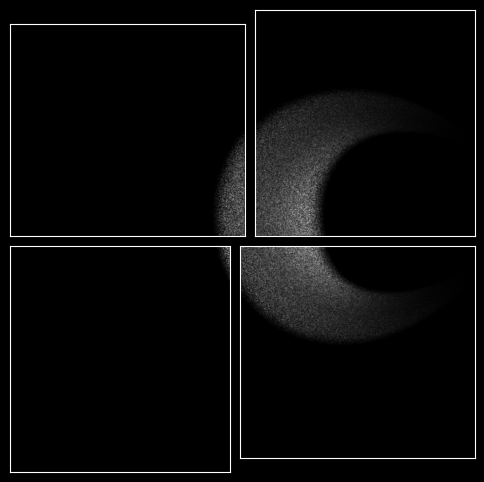

In [6]:
T = 1

L1 = 1024
L2 = 960
DL = 44

fig = plt.figure(figsize=(6, 6))
gs = GridSpec((L1 + L1 + DL), (L1 + L2 + DL))

ax1 = fig.add_subplot(gs[(L1 + DL):-64, (L2 + DL):])
ax2 = fig.add_subplot(gs[:L1, (L1 + DL):])
ax3 = fig.add_subplot(gs[64:L1, :L1])
ax4 = fig.add_subplot(gs[(L1 + DL):, :L2])

ax1.imshow(gaussian_filter(data_solo_1.get(0)[T], 1), cmap='gist_gray', origin='lower', aspect='auto')
ax1.set_xticklabels('')
ax1.set_yticklabels('')
ax1.set_xticks([])
ax1.set_yticks([])

ax2.imshow(gaussian_filter(data_solo_2.get(0)[T], 1), cmap='gist_gray', origin='lower', aspect='auto')
ax2.set_xticklabels('')
ax2.set_yticklabels('')
ax2.set_xticks([])
ax2.set_yticks([])

ax3.imshow(gaussian_filter(data_solo_3.get(0)[T], 1), cmap='gist_gray', origin='lower', aspect='auto')
ax3.set_xticklabels('')
ax3.set_yticklabels('')
ax3.set_xticks([])
ax3.set_yticks([])

ax4.imshow(gaussian_filter(data_solo_4.get(0)[T], 1), cmap='gist_gray', origin='lower', aspect='auto')
ax4.set_xticklabels('')
ax4.set_yticklabels('')
ax4.set_xticks([])
ax4.set_yticks([])

plt.show()

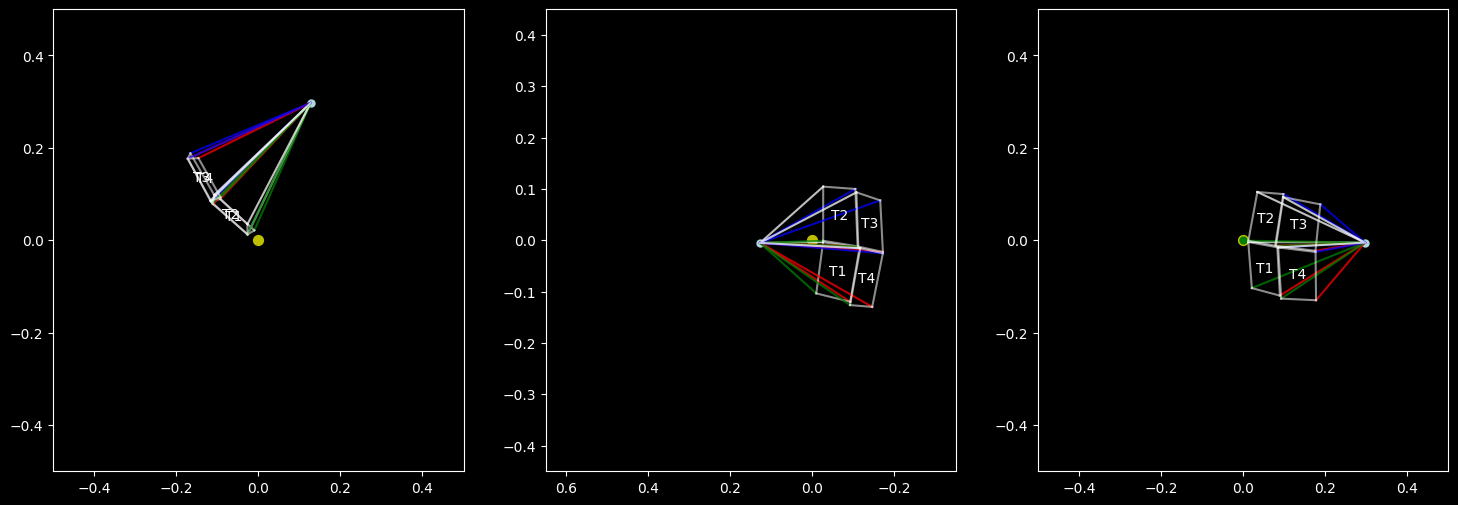

In [7]:
pos = obs_1.positions()[0] 
fovs = [obs_1.camera_fovs()[0], obs_2.camera_fovs()[0], obs_3.camera_fovs()[0], obs_4.camera_fovs()[0]]

# scale fovs by distance to sun
r_s = np.linalg.norm(pos)

fovs = [_ * r_s for _ in fovs]

DIMSL = [[0, 1], [0, 2], [1, 2]]

A1 = 0.75
A2 = 0.55

EARTH_LOC = np.array([1.0, 0, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for (ax, DIMS, axi) in zip(axes, DIMSL, list(range(3))):
    ax.set_xlim([-0.5, 0.5])
    ax.set_ylim([-0.5, 0.5])
    ax.scatter(0, 0, color='y', s=50)
    ax.scatter(*EARTH_LOC[DIMS], color='g', s=25)

    ax.scatter(*pos[DIMS], color="lightblue", s=25)

    for (id, fov) in zip(range(1, 5), fovs):
        mean = np.mean(fov + pos, axis=0)
        ax.text(*mean[DIMS], "T{}".format(id), verticalalignment="center", horizontalalignment="center")

        ax.plot(*np.array([pos, fov[0] + pos])[:, DIMS].T, color='r', alpha=A1)
        ax.plot(*np.array([pos, fov[1] + pos])[:, DIMS].T, color='g', alpha=A1)
        ax.plot(*np.array([pos, fov[2] + pos])[:, DIMS].T, color='b', alpha=A1)
        ax.plot(*np.array([pos, fov[3] + pos])[:, DIMS].T, color='w', alpha=A1)

        ax.plot(*np.array([fov[0] + pos, fov[2] + pos])[:, DIMS].T, color='w', alpha=A2)
        ax.plot(*np.array([fov[1] + pos, fov[3] + pos])[:, DIMS].T, color='w', alpha=A2)
        ax.plot(*np.array([fov[0] + pos, fov[1] + pos])[:, DIMS].T, color='w', alpha=A2)
        ax.plot(*np.array([fov[2] + pos, fov[3] + pos])[:, DIMS].T, color='w', alpha=A2)

    if axi == 1:
        ax.set_xlim(-0.35, 0.65)
        ax.set_ylim(-0.45, 0.45)
        ax.invert_xaxis()

plt.show()

NameError: name 'AGCSEnsbl' is not defined

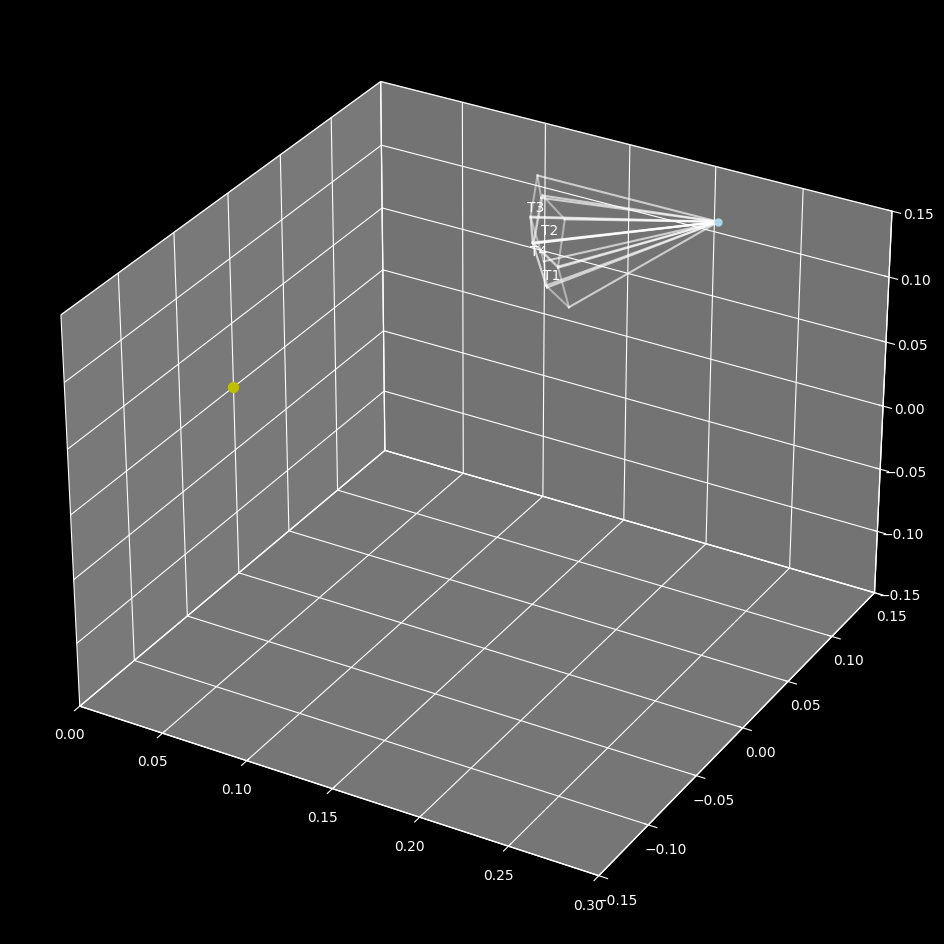

In [ ]:
# scale fovs by distance to sun
r_s = np.linalg.norm(pos)

fovs = [_ * r_s for _ in fovs]

DIMSL = [[0, 1], [0, 2], [1, 2]]

A1 = 0.65
A2 = 0.45

EARTH_LOC = np.array([1.0, 0, 0])

ax = plt.figure(figsize=(12, 12)).add_subplot(projection='3d')

ax.set_xlim([0.00, 0.3])
ax.set_ylim([-0.15, 0.15])
ax.set_zlim([-0.15, 0.15])

ax.scatter(0, 0, color='y', s=50)
ax.scatter(*EARTH_LOC, color='g', s=25)
ax.scatter(*pos, color="lightblue", s=25)

for (id, fov) in zip(range(1, 5), fovs):
    mean = np.mean(fov + pos, axis=0)
    ax.text(*mean, "T{}".format(id), verticalalignment="center", horizontalalignment="center")

    ax.plot(*np.array([pos, fov[0] + pos]).T, color='w', alpha=A1)
    ax.plot(*np.array([pos, fov[1] + pos]).T, color='w', alpha=A1)
    ax.plot(*np.array([pos, fov[2] + pos]).T, color='w', alpha=A1)
    ax.plot(*np.array([pos, fov[3] + pos]).T, color='w', alpha=A1)
    ax.plot(*np.array([fov[0] + pos, fov[2] + pos]).T, color='w', alpha=A2)
    ax.plot(*np.array([fov[1] + pos, fov[3] + pos]).T, color='w', alpha=A2)
    ax.plot(*np.array([fov[0] + pos, fov[1] + pos]).T, color='w', alpha=A2)
    ax.plot(*np.array([fov[2] + pos, fov[3] + pos]).T, color='w', alpha=A2)

params = np.array([
    np.deg2rad(-2.5),   # longitude
    np.deg2rad(0.0),  # latitude
    np.deg2rad(-95.0),    # inclination
    20.0, 
    0.3,                # diameter (real width is multiplied by delta)
    np.deg2rad(45),
    0.6, 
    2.00,   
    800.0, 
    25.0, 
    -50, 
    400.0, 
    1.0
])


# single particle ensemble for generating the output
ensbl = AGCSEnsbl(1)
ensbl.set_particle(0, params)
model.initialize_ensbl(ensbl)
model.evolve_ensbl(ensbl, 3 * 1 * 3600)

nunu, ss = np.meshgrid([np.linspace(0, 1, 25)], np.linspace(0.01, 0.99, 25))
xx, yy, zz = ensbl.wireframe(0, 1.0, nunu, ss)

ax.plot_wireframe(xx, yy, zz, alpha=0.1)
ax.view_init(15, 90)
ax.set_axis_off()

plt.show()